# 04 - Vanilla GAN on Olivetti Faces

**Generative Models - From Scratch**

A normal neural network learns to *predict* something from an input. A GAN instead learns
to **generate data**. It does so with two competing networks:

**Generator (the counterfeiter)**

```text
z -> Generator -> fake image
```

**Discriminator (the detective)**

```text
image -> Discriminator -> real / fake
```

```text
Generator:      "Can I make something that looks real?"
Discriminator:  "Can I detect whether it is fake?"
```

As the detective gets better, the counterfeiter is forced to improve too. This adversarial
game is exactly what we implement on the tiny Olivetti Faces dataset. At the end we also
test one extra question:

> Does initializing the GAN Generator with a pretrained VAE Decoder give a useful starting point?

## 2. From VAE to GAN

In the previous notebook we studied the VAE:

```text
Standard VAE:   x -> Encoder -> z -> Decoder -> x_hat
```

A Vanilla GAN removes the encoder and the likelihood story:

```text
Vanilla GAN:    z -> Generator -> fake image
                real/fake image -> Discriminator -> probability of real
```

No reconstruction loss. No KL term. The Generator is trained purely by the feedback of the
Discriminator. That single change creates both the power and the instability of GANs.

In [238]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import fetch_olivetti_faces

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


dataset shape     : (400, 4096)
pixel range       : 0.0 to 1.0
number of images  : 400
number of subjects: 40


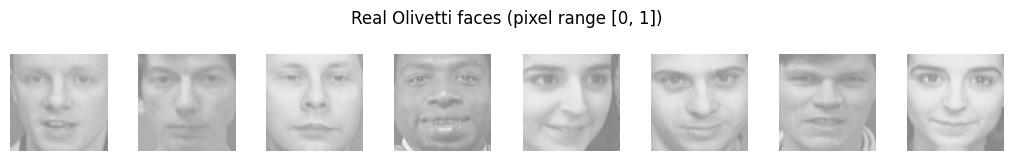

In [239]:
def show_images(batch, title=None, n=8):
    # Show one row of images shaped [n, 1, 64, 64] with values in [-1, 1].
    batch = batch.detach().cpu()
    fig, axes = plt.subplots(1, n, figsize=(n * 1.3, 1.6))
    for i, ax in enumerate(axes):
        ax.imshow(batch[i, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


olivetti = fetch_olivetti_faces(shuffle=True, random_state=SEED)

X = olivetti.data  # [400, 4096], values in [0, 1]
print("dataset shape     :", X.shape)
print("pixel range       :", X.min(), "to", X.max())
print("number of images  :", X.shape[0])
print("number of subjects:", len(np.unique(olivetti.target)))

images01 = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 64, 64)
show_images(images01[:8], "Real Olivetti faces (pixel range [0, 1])")


## 3. Preprocessing

The Generator ends with a `Tanh()` layer, whose output range is `[-1, 1]`, so we map the
images from `[0, 1]` to `[-1, 1]` with `X_scaled = 2.0 * X - 1.0` and add a channel
dimension to get `[N, 1, 64, 64]`. We keep the data handling simple and do **not** split
train/test: this is an unsupervised generative experiment.

In [240]:
X_scaled = 2.0 * X - 1.0                       # [0, 1] -> [-1, 1]
images = torch.tensor(X_scaled, dtype=torch.float32).reshape(-1, 1, 64, 64)
print("images:", tuple(images.shape),
      float(images.min()), "to", float(images.max()))

dataset = TensorDataset(images)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)
print("batches per epoch:", len(dataloader))


images: (400, 1, 64, 64) -1.0 to 1.0
batches per epoch: 13


## 4. GAN Mathematics

* `z` - random latent vector, `z ~ N(0, I)`
* `G(z)` - the generated (fake) image produced by the Generator
* `D(x)` - the Discriminator's score (logit) for image `x`

The original GAN objective is a minimax game:

$$\min_G \max_D V(D,G) = \mathbb{E}_{x\sim p_{data}}[\log D(x)] + \mathbb{E}_{z\sim p_z}[\log(1-D(G(z)))]$$

**Real-data term** - $\mathbb{E}_{x\sim p_{data}}[\log D(x)]$: the Discriminator wants real
images to receive high scores.

**Fake-data term** - $\mathbb{E}_{z\sim p_z}[\log(1-D(G(z)))]$: the Discriminator wants
generated images to receive low scores.

The Generator wants the opposite: $D(G(z)) \to 1$. The saturating form of its loss has
vanishing gradients early in training, so in practice we use the **non-saturating
Generator loss**:

$$L_G = -\mathbb{E}_z[\log D(G(z))]$$

In [241]:
# ----- Hyperparameters -----
SEED = 42

LATENT_DIM = 64
IMAGE_SIZE = 64
IMAGE_DIM = IMAGE_SIZE * IMAGE_SIZE

BATCH_SIZE = 64

GAN_EPOCHS = 350
VAE_EPOCHS = 25

LEARNING_RATE_G = 1e-4
LEARNING_RATE_D = 5e-5

# Smaller and smoother Generator
GENERATOR_HIDDEN_1 = 256
GENERATOR_HIDDEN_2 = 512
GENERATOR_HIDDEN_3 = 1024

# Slightly stronger Discriminator
DISCRIMINATOR_HIDDEN_1 = 1024
DISCRIMINATOR_HIDDEN_2 = 256

REAL_LABEL = 0.9

RUN_TRAINING = True
DEMO_EPOCHS = 2

print("Hyperparameters ready.")
print("RUN_TRAINING =", RUN_TRAINING)

Hyperparameters ready.
RUN_TRAINING = True


### Why these values?

Olivetti has only **400 images**. An overly powerful Discriminator can trivially learn
`D(real) ~ 1, D(fake) ~ 0` and dominate the Generator. So we deliberately use a **larger
Generator** and a **smaller Discriminator**, a lower Discriminator learning rate
(`5e-5` vs `1e-4`), and label smoothing (`REAL_LABEL = 0.9`). The goal is a useful
adversarial **balance**, not simply making both networks bigger.

## 5. Generator

Fully-connected Generator (no convolutions):

```text
z -> Linear 64->512   -> BatchNorm + ReLU
  -> Linear 512->1024 -> BatchNorm + ReLU
  -> Linear 1024->2048 -> BatchNorm + ReLU
  -> Linear 2048->4096 -> Tanh -> reshape -> 1 x 64 x 64
```

Shape flow (batch 32):

```text
z        [32, 64]
hidden   [32, 512]
hidden   [32, 1024]
hidden   [32, 2048]
output   [32, 4096]
image    [32, 1, 64, 64]
```

In [242]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(LATENT_DIM, GENERATOR_HIDDEN_1)
        self.bn1 = nn.BatchNorm1d(GENERATOR_HIDDEN_1)

        self.fc2 = nn.Linear(
            GENERATOR_HIDDEN_1,
            GENERATOR_HIDDEN_2
        )
        self.bn2 = nn.BatchNorm1d(GENERATOR_HIDDEN_2)

        self.fc3 = nn.Linear(
            GENERATOR_HIDDEN_2,
            GENERATOR_HIDDEN_3
        )
        self.bn3 = nn.BatchNorm1d(GENERATOR_HIDDEN_3)

        self.fc4 = nn.Linear(
            GENERATOR_HIDDEN_3,
            IMAGE_DIM
        )

    def forward(self, z):
        # z: [N, LATENT_DIM]
        h = self.fc1(z)
        h = self.bn1(h)
        h = torch.relu(h)

        # [N, 256] → [N, 512]
        h = self.fc2(h)
        h = self.bn2(h)
        h = torch.relu(h)

        # [N, 512] → [N, 1024]
        h = self.fc3(h)
        h = self.bn3(h)
        h = torch.relu(h)

        # [N, 1024] → [N, 4096]
        out = self.fc4(h)
        out = torch.tanh(out)

        # [N, 4096] → [N, 1, 64, 64]
        return out.reshape(
            -1,
            1,
            IMAGE_SIZE,
            IMAGE_SIZE
        )


generator = Generator().to(DEVICE)

print(generator)
print(
    "Generator parameters:",
    sum(p.numel() for p in generator.parameters())
)

with torch.no_grad():
    demo_z = torch.randn(
        2,
        LATENT_DIM,
        device=DEVICE
    )

    demo_out = generator(demo_z)

    print(
        "generated shape:",
        tuple(demo_out.shape)
    )


generator = Generator().to(DEVICE)
print(generator)
print("Generator parameters:", sum(p.numel() for p in generator.parameters()))

with torch.no_grad():
    demo_out = generator(torch.randn(2, LATENT_DIM, device=DEVICE))
    print("generated shape:", tuple(demo_out.shape))


Generator(
  (fc1): Linear(in_features=64, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=512, out_features=1024, bias=True)
  (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=1024, out_features=4096, bias=True)
)
Generator parameters: 4875520
generated shape: (2, 1, 64, 64)
Generator(
  (fc1): Linear(in_features=64, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=512, out_features=1024, bias=True)
  (bn3): BatchNorm1d(1024, 

## 6. Discriminator

A deliberately **smaller** MLP:

```text
1 x 64 x 64 -> Flatten -> 4096 -> 512 -> LeakyReLU -> 256 -> LeakyReLU -> 1 logit
```

There is **no final Sigmoid**: we use `BCEWithLogitsLoss`, which applies the sigmoid
internally in a numerically stable way.

In [243]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(
            IMAGE_DIM,
            DISCRIMINATOR_HIDDEN_1
        )

        self.fc2 = nn.Linear(
            DISCRIMINATOR_HIDDEN_1,
            DISCRIMINATOR_HIDDEN_2
        )

        self.fc3 = nn.Linear(
            DISCRIMINATOR_HIDDEN_2,
            1
        )

        # Small dropout can reduce overfitting on the tiny dataset.
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # [N, 1, 64, 64] → [N, 4096]
        h = x.reshape(x.size(0), -1)

        h = self.fc1(h)
        h = nn.functional.leaky_relu(h, 0.2)
        h = self.dropout(h)

        # [N, 1024] → [N, 256]
        h = self.fc2(h)
        h = nn.functional.leaky_relu(h, 0.2)
        h = self.dropout(h)

        # Raw logit: [N, 1]
        return self.fc3(h)


discriminator = Discriminator().to(DEVICE)

print(discriminator)
print(
    "Discriminator parameters:",
    sum(p.numel() for p in discriminator.parameters())
)

with torch.no_grad():
    demo_real = torch.randn(
        2,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE
    )

    demo_score = discriminator(demo_real)

    print(
        "discriminator output shape:",
        tuple(demo_score.shape)
    )

Discriminator(
  (fc1): Linear(in_features=4096, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Discriminator parameters: 4457985
discriminator output shape: (2, 1)


## 7. Why the Discriminator Is Handled Differently

With only 400 images, a big Discriminator wins the game for a long time and the Generator's
gradients become useless. So this notebook uses a large G / small D pair, a smaller
Discriminator learning rate, and one-sided label smoothing (`REAL_LABEL = 0.9` instead of
`1.0`). These are **practical stabilization choices for this educational experiment**, not a
universal GAN rule.

## 8. Build the GAN

A small helper that returns a freshly initialized Generator, Discriminator, both Adam
optimizers (`betas=(0.5, 0.999)`, a common GAN choice) and the `BCEWithLogitsLoss` criterion.

In [244]:
def build_gan():
    # Return (generator, discriminator, optimizer_G, optimizer_D, criterion).
    generator = Generator().to(DEVICE)
    discriminator = Discriminator().to(DEVICE)
    optimizer_G = torch.optim.Adam(
        generator.parameters(), lr=LEARNING_RATE_G, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(
        discriminator.parameters(), lr=LEARNING_RATE_D, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()
    return generator, discriminator, optimizer_G, optimizer_D, criterion


print("build_gan defined.")


build_gan defined.


## 9. One Explicit Training Step

**Discriminator step:** sample real images, generate fakes from random `z`, evaluate both
with D, add the real and fake BCE losses, backpropagate, update D. Crucially,
`fake_images.detach()` is used so the Discriminator update does **not** send gradients into
(and modify) the Generator.

**Generator step:** sample new `z`, generate fakes, score them with D, set the target to
`1` (here `REAL_LABEL`), backpropagate, update G. We temporarily freeze D's parameters with
`requires_grad_(False)`. Freezing D's *parameters* does **not** cut the gradient path
`G loss -> D outputs -> fake images -> G`, which is exactly the path the Generator needs in
order to learn from the Discriminator's feedback. Afterwards we unfreeze D again.

In [245]:
generator, discriminator, optimizer_G, optimizer_D, criterion = build_gan()

real_batch = next(iter(dataloader))[0].to(DEVICE)
batch = real_batch.size(0)

# ---------- Discriminator step ----------
optimizer_D.zero_grad()
z = torch.randn(batch, LATENT_DIM, device=DEVICE)
fake_images = generator(z)
real_targets = torch.full((batch, 1), REAL_LABEL, device=DEVICE)  # smoothed
fake_targets = torch.zeros(batch, 1, device=DEVICE)

d_real = discriminator(real_batch)
d_fake = discriminator(fake_images.detach())     # no gradients flow to G
d_loss = criterion(d_real, real_targets) + criterion(d_fake, fake_targets)
d_loss.backward()
optimizer_D.step()

# ---------- Generator step ----------
for parameter in discriminator.parameters():
    parameter.requires_grad_(False)              # freeze D weights

optimizer_G.zero_grad()
z = torch.randn(batch, LATENT_DIM, device=DEVICE)
fake_images = generator(z)
g_loss = criterion(discriminator(fake_images), real_targets)
g_loss.backward()                                # path: G loss -> D -> fake -> G
optimizer_G.step()

for parameter in discriminator.parameters():
    parameter.requires_grad_(True)               # unfreeze for the next step

print(f"D loss = {d_loss.item():.4f} | G loss = {g_loss.item():.4f}")
print("G received gradients through D's frozen forward pass, as intended.")


D loss = 1.3793 | G loss = 0.7586
G received gradients through D's frozen forward pass, as intended.


## 10. Full Vanilla GAN Training (500 epochs)

The complete loop: for every epoch, alternate D and G updates over all mini-batches and
average the losses and D scores. Snapshots of the same `fixed_noise` (16 latent vectors)
are saved at epochs `0, 1, 5, 10, 25, 50, 100, 150, 200, 300, 400, 500`, and four histories
are tracked: generator losses, discriminator losses, and the D(real)/D(fake) scores.

`train_gan` below is the **real full loop**. To keep the notebook practical to run from top
to bottom, `RUN_TRAINING = False` runs only `DEMO_EPOCHS` epochs. Set
`RUN_TRAINING = True` (hyperparameter cell) to run the full `GAN_EPOCHS = 500` training.

In [246]:
SNAPSHOT_EPOCHS = [0, 1, 5, 10, 25, 50, 100, 150, 200, 300, 400, 500]


def train_gan(generator, discriminator, epochs, snapshot_epochs, seed=SEED):
    # Train a Vanilla GAN; return histories, snapshots on fixed noise, and the noise.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    generator, discriminator = generator.to(DEVICE), discriminator.to(DEVICE)
    optimizer_G = torch.optim.Adam(
        generator.parameters(), lr=LEARNING_RATE_G, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(
        discriminator.parameters(), lr=LEARNING_RATE_D, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    fixed_noise = torch.randn(16, LATENT_DIM, device=DEVICE)

    generator_losses, discriminator_losses = [], []
    discriminator_real_scores, discriminator_fake_scores = [], []
    snapshots = {}

    with torch.no_grad():                        # epoch-0 snapshot (untrained G)
        snapshots[0] = generator(fixed_noise).detach().cpu()

    for epoch in range(1, epochs + 1):
        g_sum, d_sum, real_sum, fake_sum, n_batches = 0.0, 0.0, 0.0, 0.0, 0

        for (real_batch,) in dataloader:
            real_batch = real_batch.to(DEVICE)
            bs = real_batch.size(0)
            real_targets = torch.full((bs, 1), REAL_LABEL, device=DEVICE)
            fake_targets = torch.zeros(bs, 1, device=DEVICE)

            # ---------- Discriminator step ----------
            optimizer_D.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fake_images = generator(z)
            d_real = discriminator(real_batch)
            d_fake = discriminator(fake_images.detach())  # do not update G here
            d_loss = criterion(d_real, real_targets) + criterion(d_fake, fake_targets)
            d_loss.backward()
            optimizer_D.step()

            # ---------- Generator step ----------
            for parameter in discriminator.parameters():
                parameter.requires_grad_(False)              # freeze D weights
            optimizer_G.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fake_images = generator(z)
            g_loss = criterion(discriminator(fake_images), real_targets)
            g_loss.backward()                                # G learns via D
            optimizer_G.step()
            for parameter in discriminator.parameters():
                parameter.requires_grad_(True)               # unfreeze again

            g_sum += g_loss.item()
            d_sum += d_loss.item()
            real_sum += torch.sigmoid(d_real).mean().item()
            fake_sum += torch.sigmoid(d_fake).mean().item()
            n_batches += 1

        generator_losses.append(g_sum / n_batches)
        discriminator_losses.append(d_sum / n_batches)
        discriminator_real_scores.append(real_sum / n_batches)
        discriminator_fake_scores.append(fake_sum / n_batches)

        if epoch in snapshot_epochs:
            with torch.no_grad():
                snapshots[epoch] = generator(fixed_noise).detach().cpu()

        if epoch == 1 or epoch % 10 == 0 or epoch in snapshot_epochs:
            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"D loss={discriminator_losses[-1]:.4f} | "
                f"G loss={generator_losses[-1]:.4f} | "
                f"D(real)={discriminator_real_scores[-1]:.3f} | "
                f"D(fake)={discriminator_fake_scores[-1]:.3f}"
            )

    return {
        "generator_losses": generator_losses,
        "discriminator_losses": discriminator_losses,
        "discriminator_real_scores": discriminator_real_scores,
        "discriminator_fake_scores": discriminator_fake_scores,
        "snapshots": snapshots,
        "epochs": list(range(1, epochs + 1)),
        "fixed_noise": fixed_noise.detach().cpu(),
    }


gan_epochs_run = GAN_EPOCHS if RUN_TRAINING else DEMO_EPOCHS
gan_snap_epochs = (SNAPSHOT_EPOCHS if RUN_TRAINING
                   else [e for e in SNAPSHOT_EPOCHS if e <= DEMO_EPOCHS])
print(f"Training Vanilla GAN for {gan_epochs_run} epochs "
      f"({'FULL run' if RUN_TRAINING else 'DEMO fallback - set RUN_TRAINING = True for 500 epochs'})")

gan_generator, gan_discriminator = build_gan()[:2]
gan_results = train_gan(gan_generator, gan_discriminator, gan_epochs_run, gan_snap_epochs)
print("Done. Snapshot epochs:", sorted(gan_results["snapshots"].keys()))


Training Vanilla GAN for 350 epochs (FULL run)
Epoch    1/350 | D loss=1.3507 | G loss=0.6822 | D(real)=0.584 | D(fake)=0.537
Epoch    5/350 | D loss=1.2468 | G loss=0.9732 | D(real)=0.524 | D(fake)=0.445
Epoch   10/350 | D loss=1.1103 | G loss=1.1666 | D(real)=0.581 | D(fake)=0.403
Epoch   20/350 | D loss=1.1802 | G loss=1.5191 | D(real)=0.476 | D(fake)=0.351
Epoch   25/350 | D loss=1.0153 | G loss=1.6046 | D(real)=0.565 | D(fake)=0.322
Epoch   30/350 | D loss=1.0221 | G loss=1.6371 | D(real)=0.593 | D(fake)=0.342
Epoch   40/350 | D loss=1.1355 | G loss=1.6775 | D(real)=0.569 | D(fake)=0.380
Epoch   50/350 | D loss=1.0546 | G loss=1.7111 | D(real)=0.613 | D(fake)=0.364
Epoch   60/350 | D loss=1.0733 | G loss=1.6542 | D(real)=0.583 | D(fake)=0.367
Epoch   70/350 | D loss=1.0290 | G loss=1.8812 | D(real)=0.592 | D(fake)=0.337
Epoch   80/350 | D loss=1.0026 | G loss=2.1043 | D(real)=0.626 | D(fake)=0.320
Epoch   90/350 | D loss=1.1001 | G loss=1.9478 | D(real)=0.579 | D(fake)=0.345
Epoch

## 11. Discriminator Diagnostics

`D(real)` and `D(fake)` (after sigmoid) over epochs. A healthy adversarial relationship does
**not** require `D(real) = 1` and `D(fake) = 0` forever. If the Discriminator stays extremely
confident for a long period it may be dominating the game - which is exactly why we chose a
smaller D, a lower D learning rate, and label smoothing. None of these choices *guarantees*
stable GAN training.

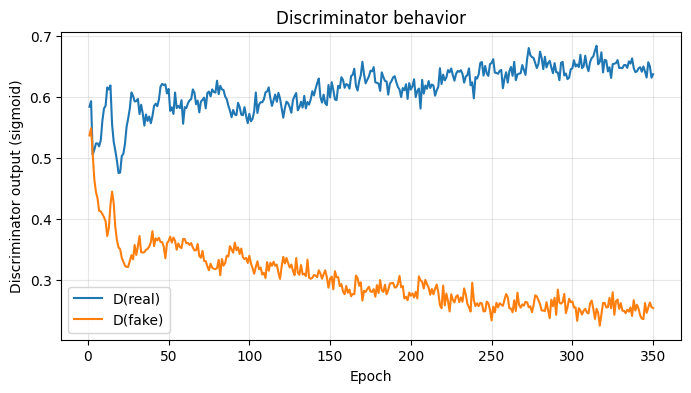

In [247]:
epochs_axis = gan_results["epochs"]

plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, gan_results["discriminator_real_scores"], label="D(real)")
plt.plot(epochs_axis, gan_results["discriminator_fake_scores"], label="D(fake)")
plt.xlabel("Epoch")
plt.ylabel("Discriminator output (sigmoid)")
plt.title("Discriminator behavior")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 12. Loss Visualization

GAN losses should **not** be read like ordinary supervised-learning losses. They may
oscillate, move up and down, and change dramatically as the opposing network improves.
A lower Generator loss is not automatically proof of better images - always look at the
generated samples and the D(real)/D(fake) curves together.

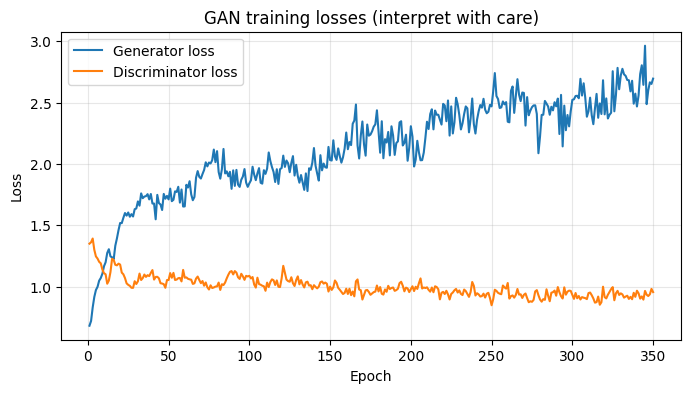

In [248]:
plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, gan_results["generator_losses"], label="Generator loss")
plt.plot(epochs_axis, gan_results["discriminator_losses"], label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN training losses (interpret with care)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 13. Training Progression on Fixed Noise

Every snapshot is generated from the **same** 16 latent vectors. This is much more
informative than sampling new noise for each plot: we see the *same z* flowing through
*different Generator checkpoints*, so the change we observe reflects the Generator learning,
not sampling noise.

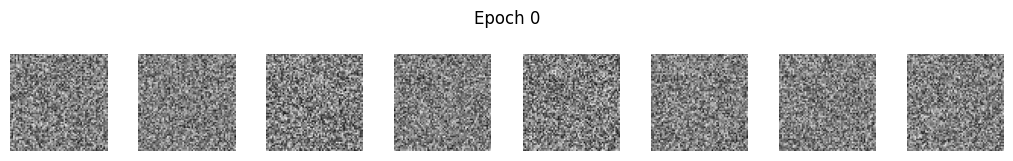

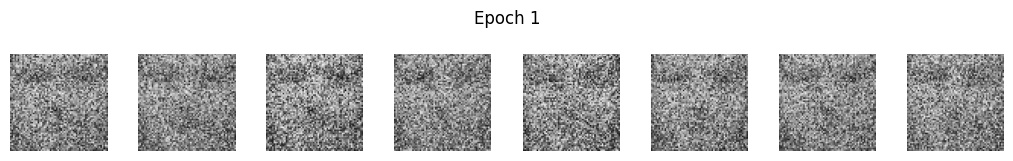

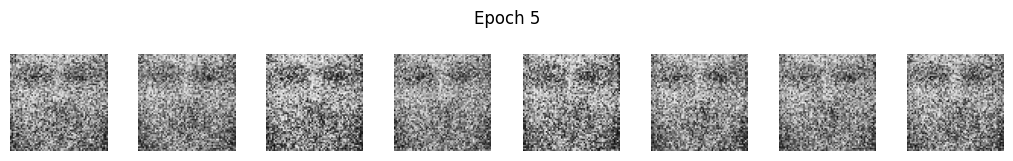

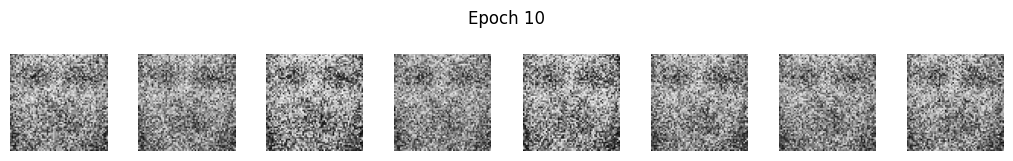

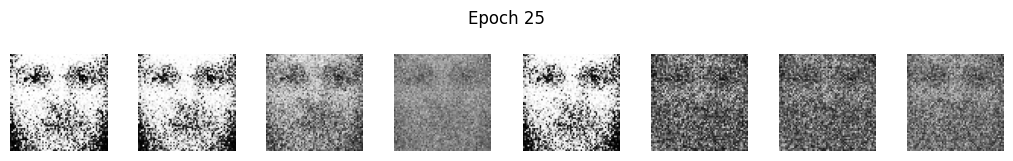

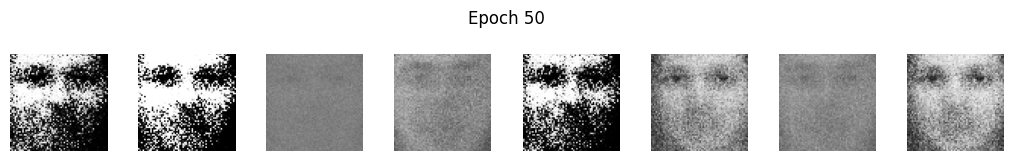

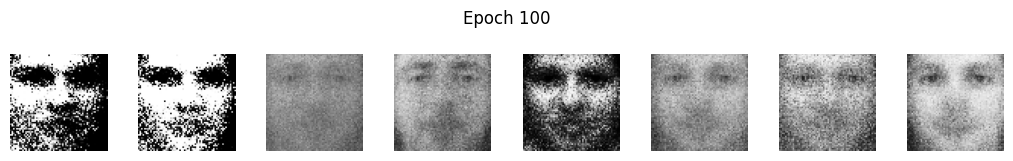

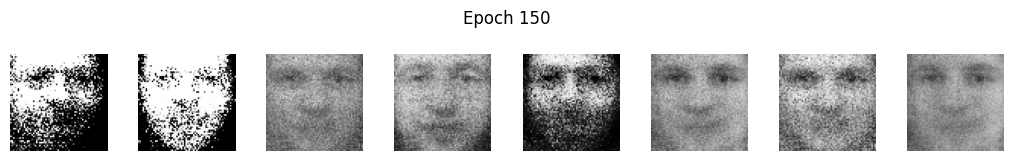

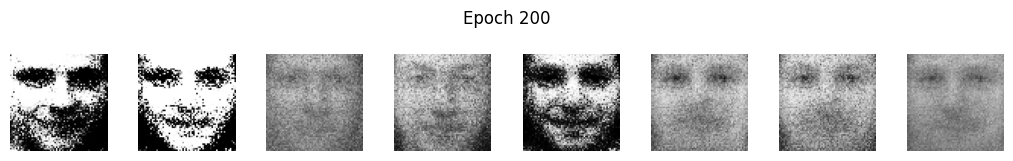

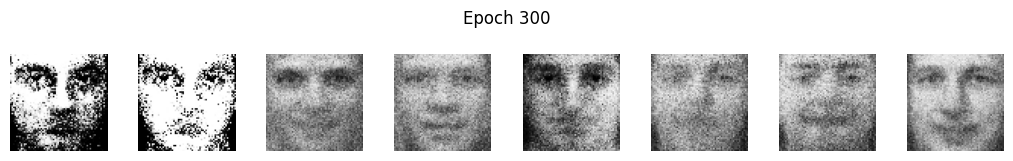

In [249]:
def plot_progression(snapshots, title_prefix="Epoch"):
    # Plot one row of 8 images for each saved snapshot epoch.
    for epoch in sorted(snapshots.keys()):
        show_images(snapshots[epoch][:8], f"{title_prefix} {epoch}", n=8)


plot_progression(gan_results["snapshots"])


## 14. Real vs Fake

Real faces in the first row, generated faces below. Judge for yourself - do not assume the
samples are "good". Inspect: face-like structure, rough head shape, grayscale patterns,
background, diversity between samples, and unrealistic artifacts.

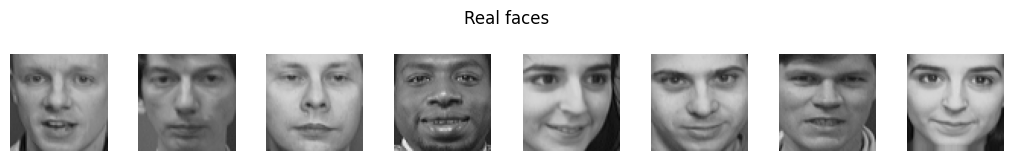

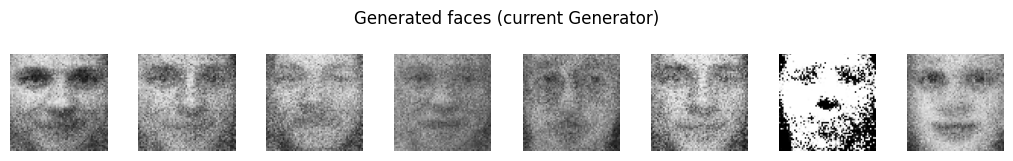

In [250]:
with torch.no_grad():
    sample_z = torch.randn(8, LATENT_DIM, device=DEVICE)
    fake_samples = gan_generator(sample_z).detach().cpu()

show_images(images[:8], "Real faces", n=8)
show_images(fake_samples, "Generated faces (current Generator)", n=8)


## 15. The Latent Vector

The Generator receives `z ~ N(0, I)` with `LATENT_DIM = 64`. The latent vector is not a
label - it is a point in the latent sampling space. Different `z` values correspond to
different (hopefully distinct) generated faces.

## 16. Latent Interpolation

We choose two latent vectors and walk between them with

$$z_\alpha = (1-\alpha)\,z_1 + \alpha\,z_2, \quad \alpha \in [0, 1]$$

generating one image per step in a single row. Smooth interpolation is an *indication* that
the learned Generator mapping changes continuously in this region of latent space - but
smoothness is **not guaranteed** everywhere.

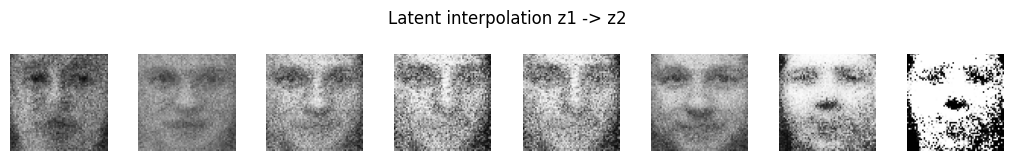

In [251]:
with torch.no_grad():
    z1 = torch.randn(1, LATENT_DIM, device=DEVICE)
    z2 = torch.randn(1, LATENT_DIM, device=DEVICE)
    alphas = torch.linspace(0, 1, 8, device=DEVICE).reshape(-1, 1)
    z_alpha = (1 - alphas) * z1 + alphas * z2            # [8, LATENT_DIM]
    interpolation = gan_generator(z_alpha).detach().cpu()

show_images(interpolation, "Latent interpolation z1 -> z2", n=8)


## 17. Latent Arithmetic (Experiment)

We try $z_{new} = z_A - z_B + z_C$ for a few random triples. **Important:** Vanilla GANs are
not explicitly trained to produce disentangled latent spaces, so meaningful arithmetic may
or may not emerge. Treat this purely as an experiment - there is no semantic guarantee.

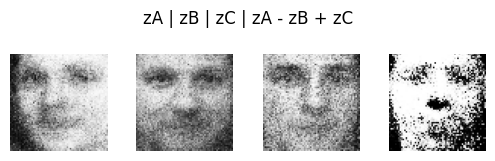

In [252]:
with torch.no_grad():
    zA = torch.randn(1, LATENT_DIM, device=DEVICE)
    zB = torch.randn(1, LATENT_DIM, device=DEVICE)
    zC = torch.randn(1, LATENT_DIM, device=DEVICE)
    z_new = zA - zB + zC
    arithmetic_row = gan_generator(torch.cat([zA, zB, zC, z_new])).detach().cpu()

show_images(arithmetic_row, "zA | zB | zC | zA - zB + zC", n=4)


## 18. VAE -> GAN Initialization Experiment

The big question of this notebook:

```text
Standard GAN:     randomly initialized Generator -> GAN training

VAE-pretrained:   VAE -> trained Decoder -> copy Decoder weights
                  -> GAN Generator -> GAN fine-tuning
```

Does VAE pretraining provide a useful starting point? We do **not** assume the answer -
we build the experiment and compare.

## 19. Small VAE (Encoder + Matching Decoder)

Encoder: `4096 -> 1024 -> 512 -> mu, logvar`.
Decoder: `64 -> 512 -> 1024 -> 2048 -> 4096 -> Tanh -> reshape` - **exactly the same
architecture as the GAN Generator**, including layer sizes, BatchNorm layers, activation
placement and final output dimension, so the learned Decoder weights can be copied directly
into the Generator.

In [253]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 4096 -> 1024 -> 512 -> mu, logvar
        self.enc_fc1 = nn.Linear(IMAGE_DIM, 1024)
        self.enc_fc2 = nn.Linear(1024, 512)
        self.enc_mu = nn.Linear(512, LATENT_DIM)
        self.enc_logvar = nn.Linear(512, LATENT_DIM)
        # Decoder: identical architecture to the GAN Generator
        self.dec_fc1 = nn.Linear(LATENT_DIM, GENERATOR_HIDDEN_1)
        self.dec_bn1 = nn.BatchNorm1d(GENERATOR_HIDDEN_1)
        self.dec_fc2 = nn.Linear(GENERATOR_HIDDEN_1, GENERATOR_HIDDEN_2)
        self.dec_bn2 = nn.BatchNorm1d(GENERATOR_HIDDEN_2)
        self.dec_fc3 = nn.Linear(GENERATOR_HIDDEN_2, GENERATOR_HIDDEN_3)
        self.dec_bn3 = nn.BatchNorm1d(GENERATOR_HIDDEN_3)
        self.dec_fc4 = nn.Linear(GENERATOR_HIDDEN_3, IMAGE_DIM)

    def encode(self, x):
        h = x.reshape(x.size(0), -1)
        h = torch.relu(self.enc_fc1(h))
        h = torch.relu(self.enc_fc2(h))
        return self.enc_mu(h), self.enc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        h = torch.relu(self.dec_bn1(self.dec_fc1(z)))
        h = torch.relu(self.dec_bn2(self.dec_fc2(h)))
        h = torch.relu(self.dec_bn3(self.dec_fc3(h)))
        out = torch.tanh(self.dec_fc4(h))
        return out.reshape(-1, 1, IMAGE_SIZE, IMAGE_SIZE)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


vae = VAE().to(DEVICE)
print(vae)
print("VAE parameters:", sum(p.numel() for p in vae.parameters()))


VAE(
  (enc_fc1): Linear(in_features=4096, out_features=1024, bias=True)
  (enc_fc2): Linear(in_features=1024, out_features=512, bias=True)
  (enc_mu): Linear(in_features=512, out_features=64, bias=True)
  (enc_logvar): Linear(in_features=512, out_features=64, bias=True)
  (dec_fc1): Linear(in_features=64, out_features=256, bias=True)
  (dec_bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec_fc2): Linear(in_features=256, out_features=512, bias=True)
  (dec_bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec_fc3): Linear(in_features=512, out_features=1024, bias=True)
  (dec_bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec_fc4): Linear(in_features=1024, out_features=4096, bias=True)
)
VAE parameters: 9661312


## 20. VAE Loss and Pretraining

Since the images live in `[-1, 1]`, the reconstruction term is the **squared error**
between input and reconstruction, and the KL term is the standard closed form for a
diagonal Gaussian:

$$L_{KL} = -
rac{1}{2}\sum_j \left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2
ight)$$

with $\sigma_j^2 = \exp(	ext{logvar}_j)$. We train the VAE for `VAE_EPOCHS = 50` epochs -
this is pretraining for the Generator initialization, not a full VAE study.

In [254]:
def vae_loss(recon, x, mu, logvar):
    # Squared reconstruction error + standard diagonal-Gaussian KL.
    recon_error = torch.sum((recon - x) ** 2)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_error + kl


vae_epochs_run = VAE_EPOCHS if RUN_TRAINING else DEMO_EPOCHS
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae.train()
for epoch in range(1, vae_epochs_run + 1):
    total = 0.0
    for (batch,) in dataloader:
        batch = batch.to(DEVICE)
        vae_optimizer.zero_grad()
        recon, mu, logvar = vae(batch)
        loss = vae_loss(recon, batch, mu, logvar)
        loss.backward()
        vae_optimizer.step()
        total += loss.item()
    if epoch == 1 or epoch % 10 == 0:
        print(f"VAE epoch {epoch:3d}/{vae_epochs_run} | loss = {total / len(dataloader):.1f}")
vae.eval()
print("VAE pretraining finished.")


VAE epoch   1/25 | loss = 19901.0
VAE epoch  10/25 | loss = 7131.4
VAE epoch  20/25 | loss = 5912.8
VAE pretraining finished.


## 21. VAE Reconstruction Check

A small sanity-check grid: real image on top, VAE reconstruction below. We do **not**
require perfect reconstruction - we only want to confirm the Decoder learned something
useful before copying its weights into the Generator.

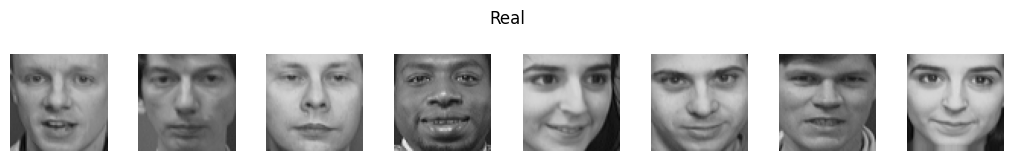

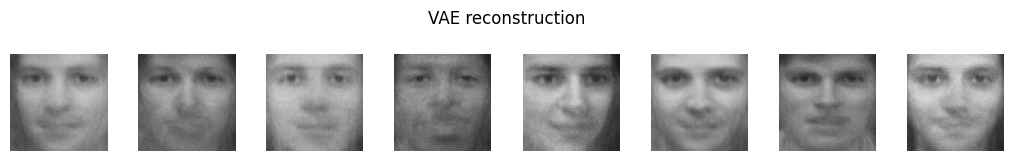

In [255]:
with torch.no_grad():
    check = images[:8].to(DEVICE)
    recon, _, _ = vae(check)

show_images(check.detach().cpu(), "Real", n=8)
show_images(recon.detach().cpu(), "VAE reconstruction", n=8)


## 22. Safe Decoder -> Generator Weight Transfer

The Decoder and the Generator must match **exactly**. `copy_decoder_to_generator` compares
the parameter-name sets and every parameter shape between the two `state_dict`s, raises a
clear `RuntimeError` on any mismatch, and only loads the weights after validation succeeds.
This guards against silent architecture mismatches.

In [256]:
def copy_decoder_to_generator(vae_model, generator_model):
    # Copy VAE Decoder weights into the GAN Generator after strict validation.
    dec_state = {
        name.replace("dec_", ""): tensor
        for name, tensor in vae_model.state_dict().items()
        if name.startswith("dec_")
    }
    gen_state = generator_model.state_dict()

    dec_names = set(dec_state.keys())
    gen_names = set(gen_state.keys())
    if dec_names != gen_names:
        missing = gen_names - dec_names
        extra = dec_names - gen_names
        raise RuntimeError(
            "Architecture mismatch between VAE Decoder and GAN Generator. "
            f"Missing in Decoder: {sorted(missing)}. "
            f"Unexpected in Decoder: {sorted(extra)}."
        )

    for name in sorted(dec_names):
        if dec_state[name].shape != gen_state[name].shape:
            raise RuntimeError(
                f"Shape mismatch for '{name}': "
                f"Decoder {tuple(dec_state[name].shape)} vs "
                f"Generator {tuple(gen_state[name].shape)}."
            )

    generator_model.load_state_dict(dec_state, strict=True)
    generator_model.to(DEVICE)
    print("VAE Decoder weights copied into GAN Generator successfully.")


copy_decoder_to_generator(vae, gan_generator)


VAE Decoder weights copied into GAN Generator successfully.


## 23. Comparison Training: Random Init vs VAE-Pretrained

We train two GANs with **identical settings** - same dataset, Generator and Discriminator
architectures, batch size, epochs, learning rates, loss function and training procedure,
and the same random seed where practical:

* **Model A** - randomly initialized Generator.
* **Model B** - Generator initialized from the VAE Decoder.

Each experiment uses its **own separate Discriminator**, and the **same fixed noise** so
that snapshots are directly comparable. All metrics (G loss, D loss, D(real), D(fake),
snapshots) are stored for both models.

In [257]:
comparison_epochs = gan_epochs_run
comparison_snap_epochs = gan_snap_epochs

# Model A: random initialization, fresh Discriminator
model_A_generator, model_A_discriminator = build_gan()[:2]
results_A = train_gan(model_A_generator, model_A_discriminator,
                      comparison_epochs, comparison_snap_epochs, seed=SEED)

# Model B: VAE-pretrained Generator, fresh separate Discriminator
model_B_generator, model_B_discriminator = build_gan()[:2]
copy_decoder_to_generator(vae, model_B_generator)
results_B = train_gan(model_B_generator, model_B_discriminator,
                      comparison_epochs, comparison_snap_epochs, seed=SEED)

print("Comparison training finished for both models.")


Epoch    1/350 | D loss=1.3541 | G loss=0.6790 | D(real)=0.586 | D(fake)=0.540
Epoch    5/350 | D loss=1.2530 | G loss=0.9597 | D(real)=0.524 | D(fake)=0.449
Epoch   10/350 | D loss=1.1083 | G loss=1.1521 | D(real)=0.581 | D(fake)=0.406
Epoch   20/350 | D loss=1.1217 | G loss=1.5580 | D(real)=0.489 | D(fake)=0.329
Epoch   25/350 | D loss=1.0101 | G loss=1.6614 | D(real)=0.569 | D(fake)=0.323
Epoch   30/350 | D loss=1.0239 | G loss=1.7453 | D(real)=0.596 | D(fake)=0.345
Epoch   40/350 | D loss=1.0584 | G loss=1.7996 | D(real)=0.562 | D(fake)=0.333
Epoch   50/350 | D loss=1.0751 | G loss=1.9636 | D(real)=0.595 | D(fake)=0.363
Epoch   60/350 | D loss=0.9926 | G loss=1.8973 | D(real)=0.640 | D(fake)=0.347
Epoch   70/350 | D loss=1.0355 | G loss=1.9288 | D(real)=0.606 | D(fake)=0.349
Epoch   80/350 | D loss=1.0759 | G loss=1.9276 | D(real)=0.570 | D(fake)=0.344
Epoch   90/350 | D loss=1.0237 | G loss=1.8352 | D(real)=0.597 | D(fake)=0.327
Epoch  100/350 | D loss=1.0401 | G loss=1.8982 | D(r

## 24. Comparison Visualizations and Interpretation

Five views of the same experiment:

1. **Training progression** on the same fixed noise for both models.
2. **Generator loss** comparison.
3. **Discriminator loss** comparison.
4. **Discriminator behavior** - D(real)/D(fake) for both models.
5. **Final samples** from the same latent vectors.

### Interpretation

* **VAE initialization may help** - useful structure may appear earlier.
* **Random initialization may catch up** - the advantage may only exist early in training.
* **VAE initialization may not help** - the VAE representation may not be an ideal starting
  point for adversarial training.

This experiment **tests a hypothesis**; it does not prove that VAE pretraining is
universally better.

--- Model A (Random init) progression ---


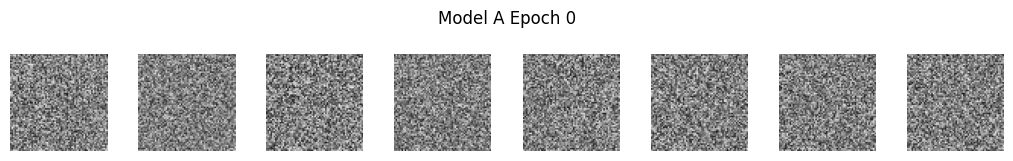

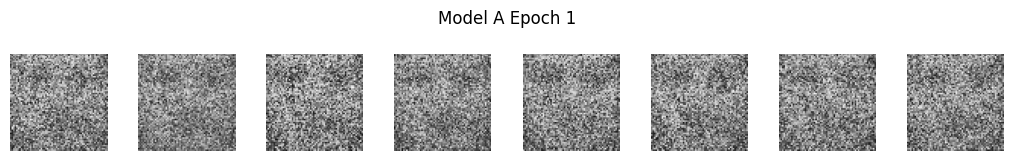

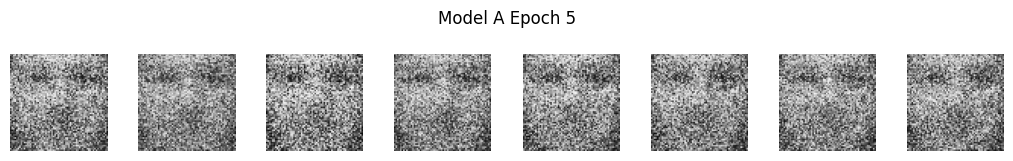

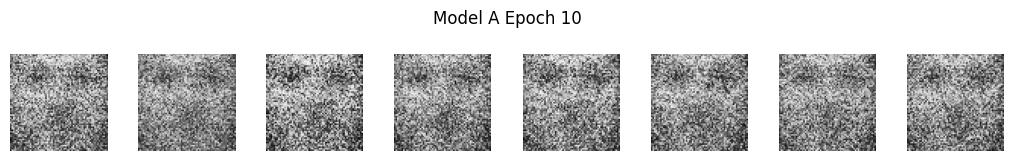

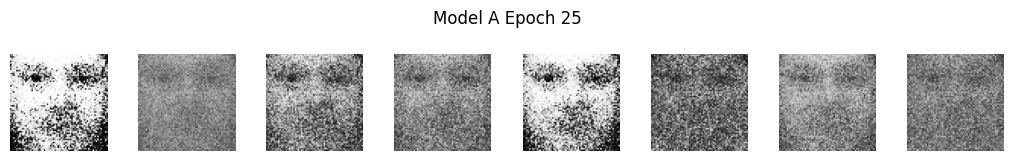

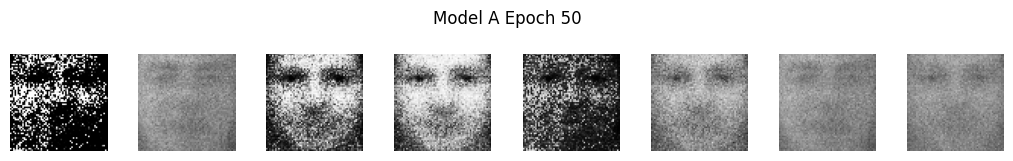

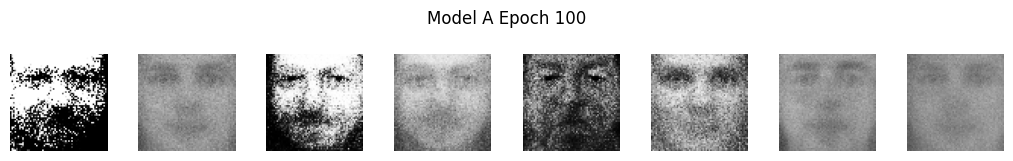

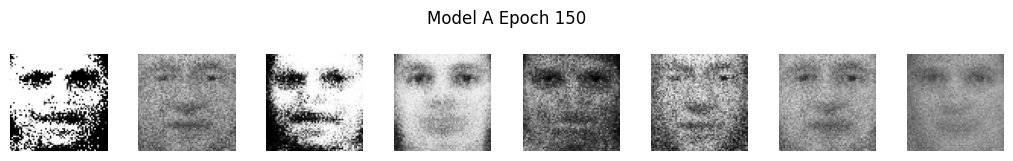

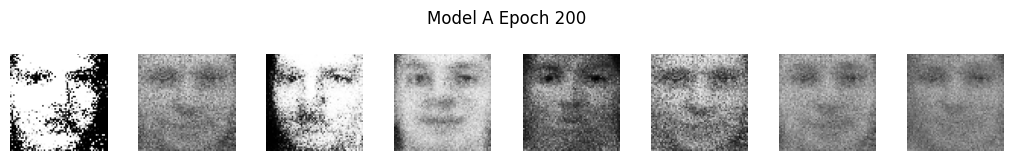

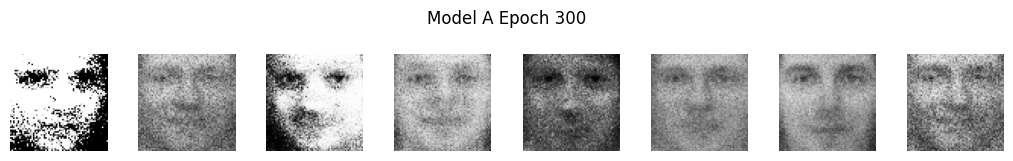

--- Model B (VAE pretrained) progression ---


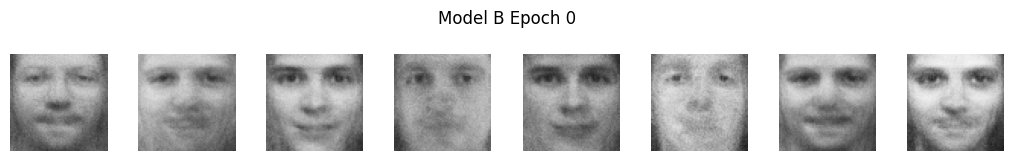

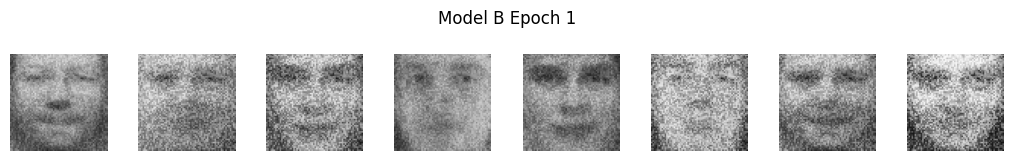

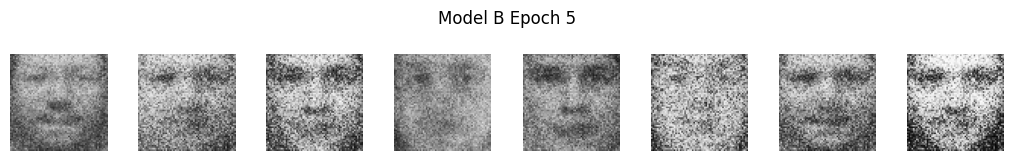

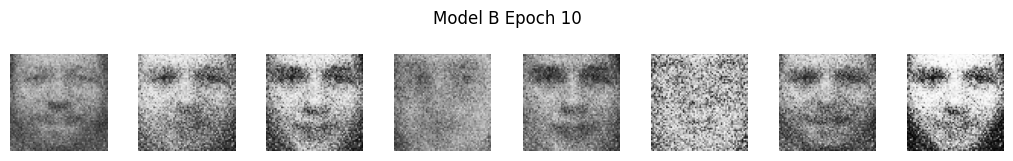

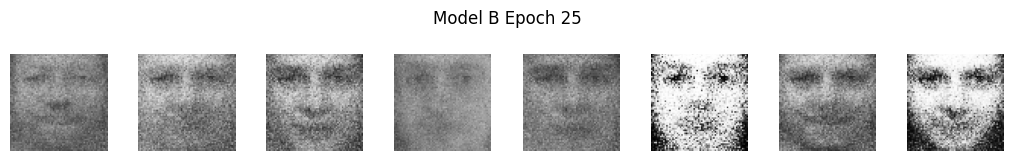

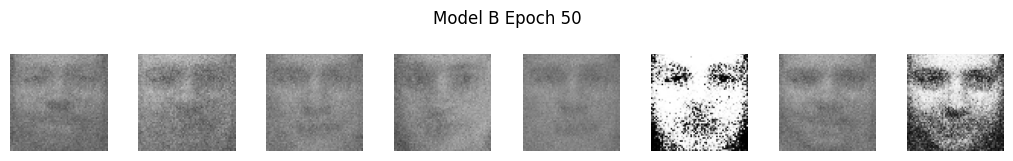

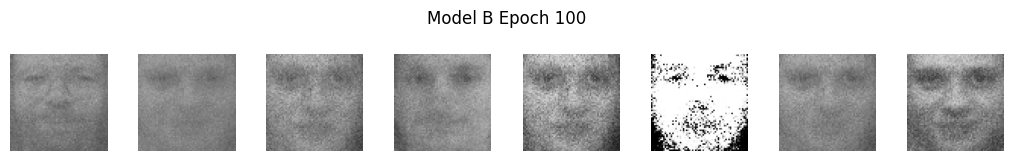

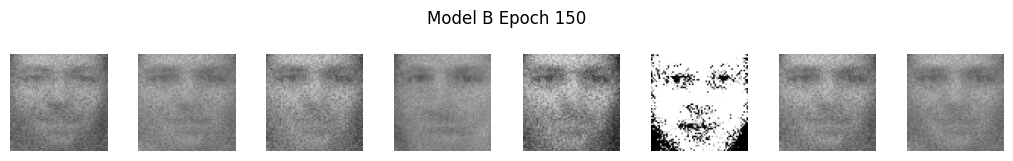

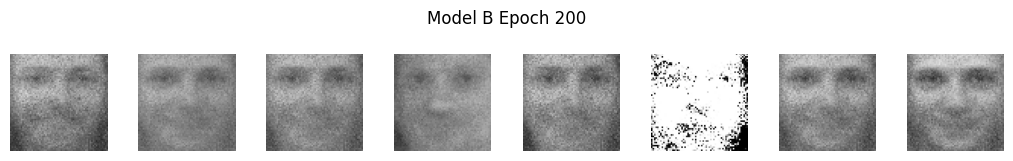

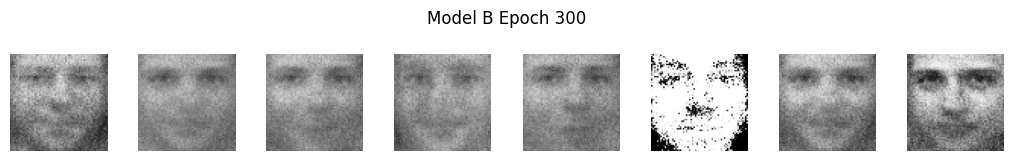

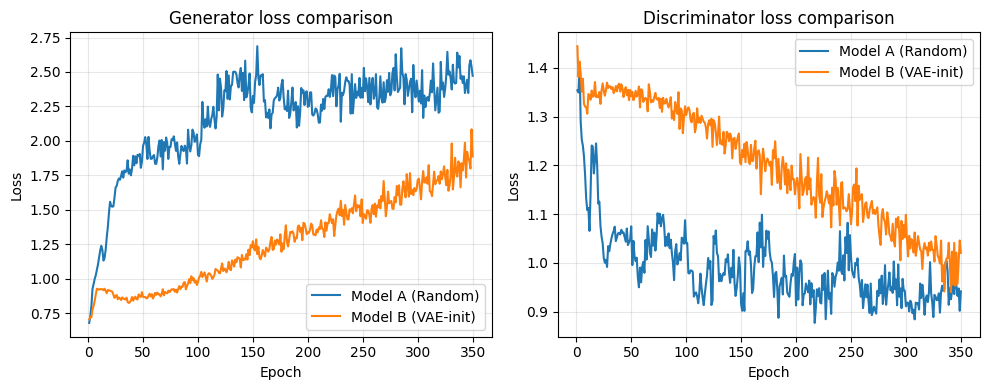

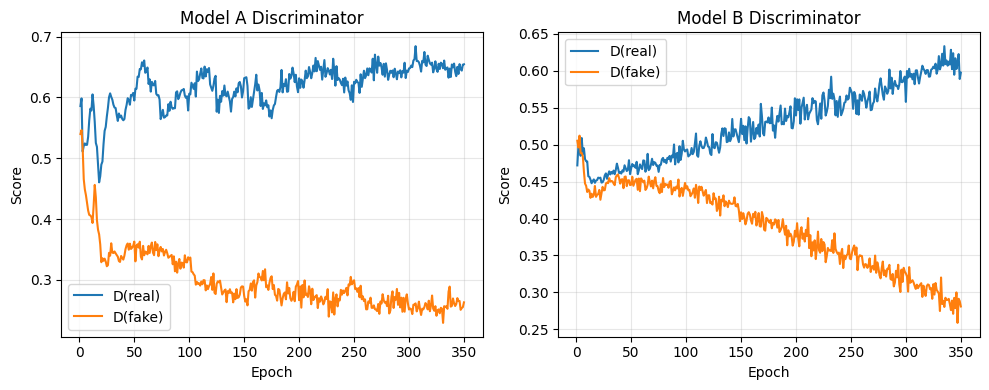

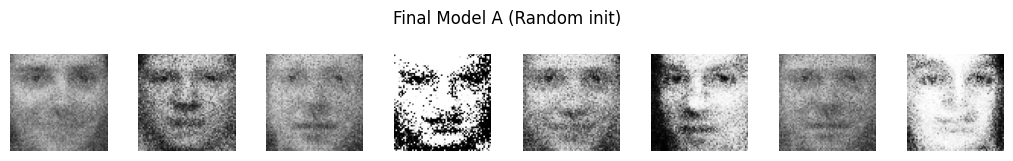

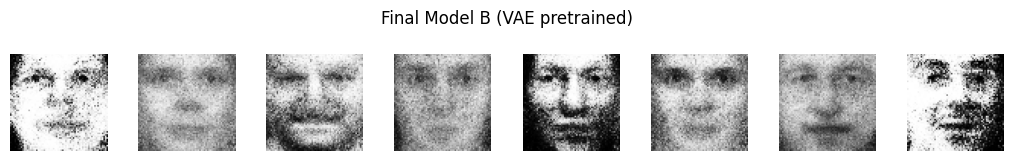

In [258]:
# A. Training progression comparison
print("--- Model A (Random init) progression ---")
plot_progression(results_A["snapshots"], title_prefix="Model A Epoch")

print("--- Model B (VAE pretrained) progression ---")
plot_progression(results_B["snapshots"], title_prefix="Model B Epoch")

# B & C. Losses
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(results_A["epochs"], results_A["generator_losses"], label="Model A (Random)")
plt.plot(results_B["epochs"], results_B["generator_losses"], label="Model B (VAE-init)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator loss comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(results_A["epochs"], results_A["discriminator_losses"], label="Model A (Random)")
plt.plot(results_B["epochs"], results_B["discriminator_losses"], label="Model B (VAE-init)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Discriminator loss comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# D. Discriminator behavior
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(results_A["epochs"], results_A["discriminator_real_scores"], label="D(real)")
plt.plot(results_A["epochs"], results_A["discriminator_fake_scores"], label="D(fake)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Model A Discriminator")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(results_B["epochs"], results_B["discriminator_real_scores"], label="D(real)")
plt.plot(results_B["epochs"], results_B["discriminator_fake_scores"], label="D(fake)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Model B Discriminator")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# E. Final samples on the same noise
final_noise = torch.randn(8, LATENT_DIM, device=DEVICE)
with torch.no_grad():
    final_A = model_A_generator(final_noise).detach().cpu()
    final_B = model_B_generator(final_noise).detach().cpu()

show_images(final_A, "Final Model A (Random init)", n=8)
show_images(final_B, "Final Model B (VAE pretrained)", n=8)


## 25. GAN Failure Modes

* **Mode collapse** - the Generator maps many different latent vectors to the same (or very
  few) images, ignoring the diversity of the real dataset.
* **Discriminator dominance** - D learns too quickly, driving $D(	ext{real}) \approx 1$ and
  $D(	ext{fake}) \approx 0$; the non-saturating loss becomes flat and G receives near-zero
  gradients.
* **Unstable training** - the two networks oscillate wildly instead of converging toward a
  balanced equilibrium.
* **Noisy outputs** - the Generator produces noisy, incoherent patterns that do not resemble
  faces, often when the learning rate is too high or the balance is lost early.

## 26. Final Mental Model

1. **Generator starts from random noise.**
2. **Generator creates fake images.**
3. **Discriminator receives real and fake images.**
4. **Discriminator learns to distinguish them.**
5. **Generator learns from the Discriminator's feedback.**
6. **The two networks form an adversarial game.**
7. **`z` controls where the Generator samples from its learned distribution.**
8. **Latent interpolation lets us inspect the learned latent space.**
9. **VAE pretraining can be tested as an alternative Generator initialization.**
10. **GAN losses must be interpreted together with generated samples and D(real)/D(fake).**

## 27. Comparison With VAE

| Model | Generation input | Main mechanism |
| :--- | :--- | :--- |
| **VAE** | `z ~ N(0, I)` | Reconstruction loss + KL divergence |
| **GAN** | `z ~ N(0, I)` | Adversarial minimax competition |

* **VAE:** learns a structured, probabilistic latent representation with explicit likelihood
  optimization. Often produces slightly blurry reconstructions because of pixel-level MSE.
* **GAN:** learns to generate sharp samples purely through competition with a Discriminator,
  without an encoder and without an explicit likelihood function.

## 28. Common Mistakes

* **Mistake 1 - Updating G during the D step.**
  `fake_images.detach()` is required so that the Discriminator's backward pass does not
  compute or accumulate gradients into the Generator parameters.
* **Mistake 2 - Updating D during the G step.**
  Temporarily freeze D with `for p in d.parameters(): p.requires_grad_(False)`. This stops D
  from changing while still allowing gradients to flow *through* D back to G.
* **Mistake 3 - Adding Sigmoid before `BCEWithLogitsLoss`.**
  `BCEWithLogitsLoss` combines a `Sigmoid` layer and standard BCE into a single, numerically
  stable operation using the log-sum-exp trick. An extra `Sigmoid` squashes logits twice.
* **Mistake 4 - Mismatched Generator and VAE Decoder.**
  Direct weight transfer requires identical layer dimensions, layer names, and BatchNorm
  configurations. Always validate `state_dict` keys and shapes before loading.
* **Mistake 5 - Using `view()` on a non-contiguous tensor.**
  Use `reshape(...)` instead of `view(...)` to avoid runtime errors whenever tensor memory is
  non-contiguous.
* **Mistake 6 - Interpreting GAN loss like supervised-learning loss.**
  GAN losses oscillate naturally. A falling Generator loss does not necessarily mean higher
  visual quality, and a rising Discriminator loss can mean G is improving.

## 29. Try It Yourself

1. Change `LATENT_DIM` from `64` to `32` and compare visual diversity.
2. Increase or decrease Generator hidden dimensions (`512 -> 1024 -> 2048`).
3. Change the Discriminator learning rate (e.g. try `1e-4` matching G) and watch for dominance.
4. Compare one-sided label smoothing (`REAL_LABEL = 0.9`) with hard labels (`1.0`).
5. Change `GAN_EPOCHS` and see at what epoch face silhouettes emerge.
6. Compare several latent interpolation pairs ($z_1 	o z_2$).
7. Run the random vs VAE initialization comparison with a different seed.
8. Generate a large batch of samples (e.g. 64) and check for mode collapse.
9. Make the Discriminator slightly larger (add a layer or wider hidden sizes) and observe dominance.
10. Make the Discriminator smaller (e.g. single hidden layer) and observe whether G can still learn.